# === Imports ===

### === Core scientific stack ===

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle, json, time, warnings
warnings.filterwarnings("ignore")

### === Signal processing ===

In [4]:
from scipy import signal as sgn
from scipy.stats import skew, kurtosis
import wfdb                             # MIT-BIH + PTB-XL (.dat/.hea/.atr)

### === Anomaly detection + evaluation ===

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_fscore_support,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, jaccard_score)

### === Plotting ===

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline

In [7]:
# import torch
# import torch.nn as nn

# === Project root ===

In [8]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR  = PROJECT_ROOT / "Dataset"

# === Signal dataset paths ===

In [9]:
PPGDALIA_DIR = DATASET_DIR / "ppg+dalia" / "data" / "PPG_FieldStudy"
WESAD_DIR    = DATASET_DIR / "WESAD"
MITBIH_DIR   = DATASET_DIR / "mit-bih-arrhythmia-database-1.0.0" / "mit-bih-arrhythmia-database-1.0.0"
PTBXL_DIR    = DATASET_DIR / "ptb-xl-1.0.3"

# === Sampling rates (Hz) ===

In [10]:
FS_CHEST = 700      # RespiBAN: ECG, EDA, EMG, RESP, TEMP, ACC
FS_WRIST_BVP = 64   # Empatica E4: BVP/PPG
FS_WRIST_EDA = 4    # Empatica E4: EDA
FS_WRIST_TMP = 4    # Empatasetica E4: TEMP
FS_WRIST_ACC = 32   # Empatica E4: ACC
FS_MITBIH = 360
FS_PTBXL  = 100     # use records100/ for v1

# === Windowing ===

In [11]:
WIN_SEC = 30
WIN_SAMPLES_CHEST = FS_CHEST * WIN_SEC      # 21,000
WIN_SAMPLES_WRIST_BVP = FS_WRIST_BVP * WIN_SEC  # 1,920

# === Reproducibility ===

In [12]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === Output ===

In [13]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print("Outputs →", OUTPUT_DIR)

Outputs → d:\All_Folder\data project\new_papers\Retrieval-augmented generation for continuous anomaly alerts\outputs


# === Load Dataset ===

### === PPG-DaLiA loader ===

In [17]:
def load_ppgdalia(subject):
    """
    Load one PPG-DaLiA subject.
    Returns dict with chest (700 Hz) and wrist (64/4 Hz) arrays + activity label.
    """
    path = PPGDALIA_DIR / f"S{subject}" / f"S{subject}.pkl"
    with open(path, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    chest = d["signal"]["chest"]
    wrist = d["signal"]["wrist"]
    return {
        "subject":    subject,
        "ecg":        chest["ECG"].ravel(),       # 700 Hz
        "eda":        chest["EDA"].ravel(),       # 700 Hz
        "resp":       chest["Resp"].ravel(),      # 700 Hz
        "temp":       chest["Temp"].ravel(),      # 700 Hz
        "bvp":        wrist["BVP"].ravel(),       # 64 Hz  (PPG)
        "wrist_eda":  wrist["EDA"].ravel(),       # 4 Hz
        "wrist_temp": wrist["TEMP"].ravel(),      # 4 Hz
        "activity":   d["label"].ravel(),         # 700 Hz grid
    }

In [20]:
d1 = load_ppgdalia(1)
for k, v in d1.items():
    if hasattr(v, "shape"):
        print(f"{k:12s} shape={v.shape}")
    else:
        print(f"{k:12s} value={v}")

subject      value=1
ecg          shape=(6448400,)
eda          shape=(6448400,)
resp         shape=(6448400,)
temp         shape=(6448400,)
bvp          shape=(589568,)
wrist_eda    shape=(36848,)
wrist_temp   shape=(36848,)
activity     shape=(4603,)


# === Data Quality Check & Cleaning ===

### === check cell ===

In [30]:
def quality_report(data):
    """Print a data quality report for one loaded subject."""
    channels = ["ecg","eda","resp","temp","bvp","wrist_eda","wrist_temp"]
    print(f"--- Subject {data['subject']} quality report ---")
    for ch in channels:
        sig = data[ch]
        n_nan      = np.isnan(sig).sum()
        n_inf      = np.isinf(sig).sum()
        n_zeros    = (sig == 0).sum()
        is_constant = np.all(sig == sig[0])
        pct_nan    = 100 * n_nan / len(sig)
        print(f"{ch:12s} | len={len(sig):>8} | NaN={n_nan:>5} ({pct_nan:4.1f}%) "
              f"| Inf={n_inf:>3} | zeros={n_zeros:>6} | constant={is_constant}")

In [31]:
quality_report(d1)

--- Subject 1 quality report ---
ecg          | len= 6448400 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=   342 | constant=False
eda          | len= 6448400 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=6448400 | constant=True
resp         | len= 6448400 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=   938 | constant=False
temp         | len= 6448400 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=     0 | constant=True
bvp          | len=  589568 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=    36 | constant=False
wrist_eda    | len=   36848 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=     0 | constant=False
wrist_temp   | len=   36848 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=     0 | constant=False


### === The fix: adaptive channel selection ===

### === clean_signal ===

In [32]:
def clean_signal(sig):
    """Clean a 1-D signal: kill Inf, interpolate short NaN gaps."""
    s = np.asarray(sig, dtype=float).copy()
    s[np.isinf(s)] = np.nan
    if np.isnan(s).any():
        idx = np.arange(len(s))
        good = ~np.isnan(s)
        if good.sum() < 10:
            return s
        s = np.interp(idx, idx[good], s[good])
    return s

### === clean_subject ===

In [33]:
def clean_subject(data):
    """Apply clean_signal to every channel in a subject dict."""
    out = {"subject": data["subject"]}
    for ch in ["ecg","eda","resp","temp","bvp","wrist_eda","wrist_temp"]:
        out[ch] = clean_signal(data[ch])
    return out

### === good_channels ===

In [34]:
def good_channels(data):
    """Return list of channels that are not constant for this subject."""
    alive = []
    for ch in ["ecg","eda","resp","temp","bvp","wrist_eda","wrist_temp"]:
        s = np.asarray(data[ch], dtype=float)
        if len(s) > 0 and not np.all(s == s[0]):
            alive.append(ch)
    return alive

### === Verify cleaning on S1 ===

In [35]:
d1_clean = clean_subject(d1)
print("Alive:", good_channels(d1_clean))

Alive: ['ecg', 'resp', 'bvp', 'wrist_eda', 'wrist_temp']


### === Audit all 15 subjects ===

In [36]:
print(f"{'Subj':>4} {'ECG':>5} {'EDA':>5} {'RESP':>5} {'TEMP':>5} {'BVP':>5} {'wEDA':>5} {'wTEMP':>5}")
for i in range(1, 16):
    try:
        d = load_ppgdalia(i)
        d = clean_subject(d)
        alive = good_channels(d)
        row = "  Y" if "ecg" in alive else "  -"
        row += "  Y" if "eda" in alive else "  -"
        row += "  Y" if "resp" in alive else "  -"
        row += "  Y" if "temp" in alive else "  -"
        row += "  Y" if "bvp" in alive else "  -"
        row += "  Y" if "wrist_eda" in alive else "  -"
        row += "  Y" if "wrist_temp" in alive else "  -"
        print(f"S{i:>2} {row}")
        del d
    except Exception as e:
        print(f"S{i:>2}  ERROR: {e}")

Subj   ECG   EDA  RESP  TEMP   BVP  wEDA wTEMP
S 1   Y  -  Y  -  Y  Y  Y
S 2   Y  -  Y  -  Y  Y  Y
S 3   Y  -  Y  -  Y  Y  Y
S 4   Y  -  Y  -  Y  Y  Y
S 5   Y  -  Y  -  Y  Y  Y
S 6   Y  -  Y  -  Y  Y  Y
S 7   Y  -  Y  -  Y  Y  Y
S 8   Y  -  Y  -  Y  Y  Y
S 9   Y  -  Y  -  Y  Y  Y
S10   Y  -  Y  -  Y  Y  Y
S11   Y  -  Y  -  Y  Y  Y
S12   Y  -  Y  -  Y  Y  Y
S13   Y  -  Y  -  Y  Y  Y
S14   Y  -  Y  -  Y  Y  Y
S15   Y  -  Y  -  Y  Y  Y


### === Global channel list (drop dead channels) ===

In [37]:
# Drop chest EDA and chest TEMP — dead (constant) for all 15 subjects
CHANNELS = ["ecg", "resp", "bvp", "wrist_eda", "wrist_temp"]
print("Channels used:", CHANNELS)
print("Dead channels dropped: chest EDA, chest TEMP")

Channels used: ['ecg', 'resp', 'bvp', 'wrist_eda', 'wrist_temp']
Dead channels dropped: chest EDA, chest TEMP


# === Featurize & Windowing ===

### === Featurize ===

In [38]:
def featurize(window):
    """Turn a 1-D signal window into 12 summary stats."""
    w = np.asarray(window).ravel().astype(float)
    return [
        w.mean(), w.std(), w.min(), w.max(), np.ptp(w),
        np.median(w), skew(w), kurtosis(w),
        np.percentile(w, 25), np.percentile(w, 75),
        np.sum(np.diff(w) > 0) / len(w),
        np.sqrt(np.mean(np.diff(w) ** 2)),
    ]
FEATURE_NAMES = ["mean","std","min","max","ptp","median","skew","kurt",
                 "p25","p75","up_ratio","roughness"]
FS_MAP = {"ecg":700, "resp":700, "bvp":64, "wrist_eda":4, "wrist_temp":4}

### === make Windows ===

In [39]:
def make_windows(sig, fs, win_sec=WIN_SEC):
    """Slice a 1-D signal into non-overlapping windows."""
    n = fs * win_sec
    return [sig[i:i+n] for i in range(0, len(sig)-n, n)]

### === Featurize subject ===

In [40]:
def featurize_subject(data, channels=CHANNELS):
    """Window + featurize all channels for one subject. Returns (X, n_windows)."""
    feats_list = []
    n_windows = None
    for ch in channels:
        wins = make_windows(data[ch], fs=FS_MAP[ch])
        feats = np.array([featurize(w) for w in wins])
        if n_windows is None:
            n_windows = feats.shape[0]
        feats_list.append(feats[:n_windows])
    X = np.hstack(feats_list)
    return X, n_windows

### === Verify on S1 ===

In [41]:
X1, n = featurize_subject(d1_clean)
print(f"Windows: {n}")
print(f"Feature matrix shape: {X1.shape}")
print(f"Expected: ({n}, {len(CHANNELS)*len(FEATURE_NAMES)})")

Windows: 307
Feature matrix shape: (307, 60)
Expected: (307, 60)


### === Loop over all 15 subjects ===

In [42]:
X_list = []
meta_list = []   # track which subject/window each row came from
for i in range(1, 16):
    print(f"Processing S{i}...", end=" ")
    d = load_ppgdalia(i)
    d = clean_subject(d)
    X, n = featurize_subject(d, channels=CHANNELS)
    X_list.append(X)
    meta_list.append(pd.DataFrame({
        "subject": i,
        "window_idx": np.arange(n),
        "t_start_sec": np.arange(n) * WIN_SEC,
        "t_end_sec": np.arange(n) * WIN_SEC + WIN_SEC,
    }))
    print(f"{n} windows")
    del d   # free memory
X_all = np.vstack(X_list)
meta_all = pd.concat(meta_list, ignore_index=True)
print(f"\nX_all shape: {X_all.shape}")
print(f"meta_all shape: {meta_all.shape}")

Processing S1... 307 windows
Processing S2... 273 windows
Processing S3... 291 windows
Processing S4... 304 windows
Processing S5... 310 windows
Processing S6... 174 windows
Processing S7... 311 windows
Processing S8... 269 windows
Processing S9... 285 windows
Processing S10... 354 windows
Processing S11... 301 windows
Processing S12... 263 windows
Processing S13... 304 windows
Processing S14... 298 windows
Processing S15... 264 windows

X_all shape: (4308, 60)
meta_all shape: (4308, 4)


### === Quick sanity check ===

In [43]:
print("NaN check:", np.isnan(X_all).sum())
print("Inf check:", np.isinf(X_all).sum())

NaN check: 0
Inf check: 0


 # === Anomaly Detection ===

 ### ===  Scale features ===

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
print("Scaled shape:", X_scaled.shape)
print("Mean ~0:", X_scaled.mean(axis=0).mean().round(4))
print("Std  ~1:", X_scaled.std(axis=0).mean().round(4))

Scaled shape: (4308, 60)
Mean ~0: 0.0
Std  ~1: 1.0


 ### === Train Isolation Forest ===

In [45]:
iforest = IsolationForest(
    n_estimators=100,
    contamination=0.05,      # expect ~5% anomalies
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iforest.fit(X_scaled)
# Score: higher = more anomalous
scores_if = -iforest.score_samples(X_scaled)
print("IF scores — min:", scores_if.min().round(3),
      " max:", scores_if.max().round(3),
      " mean:", scores_if.mean().round(3))

IF scores — min: 0.358  max: 0.644  mean: 0.423


 ### === Train KNN-LOF ===

In [46]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    n_jobs=-1
)
lof.fit(X_scaled)
# Score: higher = more anomalous
scores_lof = -lof.negative_outlier_factor_
print("LOF scores — min:", scores_lof.min().round(3),
      " max:", scores_lof.max().round(3),
      " mean:", scores_lof.mean().round(3))

LOF scores — min: 0.962  max: 4.98  mean: 1.089


 ### === Flag anomalies (top 5% by each model) ===

In [47]:
threshold_if  = np.percentile(scores_if, 95)
threshold_lof = np.percentile(scores_lof, 95)
flags_if  = scores_if > threshold_if
flags_lof = scores_lof > threshold_lof
print(f"IF  flagged: {flags_if.sum()} windows ({100*flags_if.mean():.1f}%)")
print(f"LOF flagged: {flags_lof.sum()} windows ({100*flags_lof.mean():.1f}%)")
print(f"Both agree:  {(flags_if & flags_lof).sum()} windows")

IF  flagged: 216 windows (5.0%)
LOF flagged: 216 windows (5.0%)
Both agree:  34 windows


# ===  Jaccard Agreement & Visualization ===

### === Jaccard agreement (IF vs LOF) ===

In [48]:
jaccard = jaccard_score(flags_if, flags_lof)
overlap = (flags_if & flags_lof).sum()
union   = (flags_if | flags_lof).sum()
print(f"Overlap (both flag): {overlap}")
print(f"Union  (either flag): {union}")
print(f"Jaccard agreement: {jaccard:.3f}")

Overlap (both flag): 34
Union  (either flag): 398
Jaccard agreement: 0.085


### === Score distribution plot ===

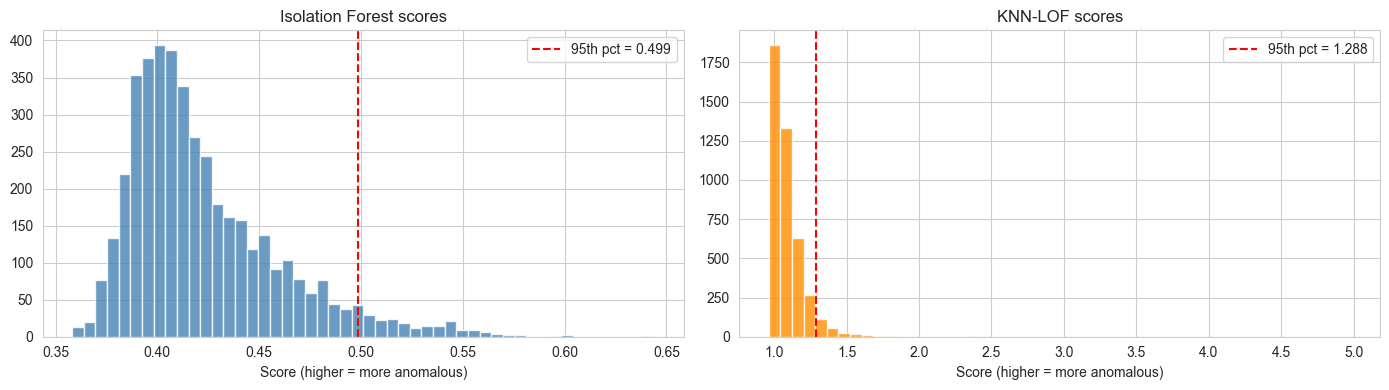

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scores_if, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(threshold_if, color="red", ls="--", label=f"95th pct = {threshold_if:.3f}")
axes[0].set_title("Isolation Forest scores")
axes[0].set_xlabel("Score (higher = more anomalous)")
axes[0].legend()
axes[1].hist(scores_lof, bins=50, color="darkorange", edgecolor="white", alpha=0.8)
axes[1].axvline(threshold_lof, color="red", ls="--", label=f"95th pct = {threshold_lof:.3f}")
axes[1].set_title("KNN-LOF scores")
axes[1].set_xlabel("Score (higher = more anomalous)")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "score_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### === Flagged windows per subject ===

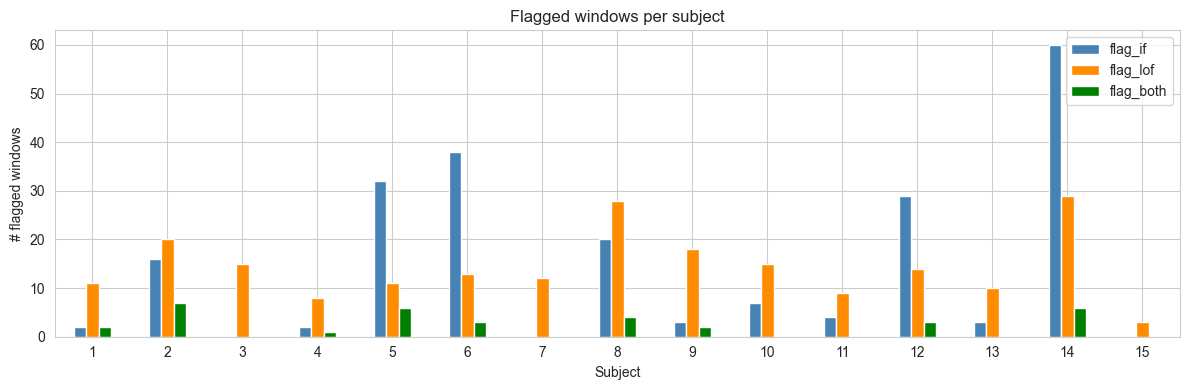

In [50]:
meta_all["flag_if"]  = flags_if
meta_all["flag_lof"] = flags_lof
meta_all["flag_both"] = flags_if & flags_lof
counts = meta_all.groupby("subject")[["flag_if","flag_lof","flag_both"]].sum()
counts.plot(kind="bar", figsize=(12, 4),
            color=["steelblue","darkorange","green"])
plt.title("Flagged windows per subject")
plt.ylabel("# flagged windows")
plt.xlabel("Subject")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "flags_per_subject.png", dpi=120, bbox_inches="tight")
plt.show()

In [51]:
print(counts)

         flag_if  flag_lof  flag_both
subject                              
1              2        11          2
2             16        20          7
3              0        15          0
4              2         8          1
5             32        11          6
6             38        13          3
7              0        12          0
8             20        28          4
9              3        18          2
10             7        15          0
11             4         9          0
12            29        14          3
13             3        10          0
14            60        29          6
15             0         3          0


# === Export flagged windows ===

### === Build named feature columns ===

In [52]:
feat_cols = [f"{ch}__{fn}" for ch in CHANNELS for fn in FEATURE_NAMES]
print("Example columns:", feat_cols[:4], "...", feat_cols[-2:])
print("Total feature columns:", len(feat_cols))

Example columns: ['ecg__mean', 'ecg__std', 'ecg__min', 'ecg__max'] ... ['wrist_temp__up_ratio', 'wrist_temp__roughness']
Total feature columns: 60


### ===  Assemble the export dataframe ===

In [53]:
df_export = meta_all.copy()
df_export["score_if"]  = scores_if.round(4)
df_export["score_lof"] = scores_lof.round(4)
# attach features with names
feat_df = pd.DataFrame(X_all, columns=feat_cols)
df_export = pd.concat([df_export, feat_df], axis=1)
# keep only windows flagged by EITHER model (the anomalies)
df_flagged = df_export[df_export["flag_both"] | df_export["flag_if"] | df_export["flag_lof"]].copy()
df_flagged.reset_index(drop=True, inplace=True)
print(f"All windows:     {len(df_export)}")
print(f"Flagged windows: {len(df_flagged)}  (these go to RAG)")
print(df_flagged[["subject","t_start_sec","t_end_sec","score_if","score_lof","flag_if","flag_lof","flag_both"]].head())

All windows:     4308
Flagged windows: 398  (these go to RAG)
   subject  t_start_sec  t_end_sec  score_if  score_lof  flag_if  flag_lof  \
0        1           30         60    0.4335     1.3521    False      True   
1        1          180        210    0.4375     1.3580    False      True   
2        1          390        420    0.4250     1.2885    False      True   
3        1         2280       2310    0.4428     1.3334    False      True   
4        1         2940       2970    0.5264     1.5333     True      True   

   flag_both  
0      False  
1      False  
2      False  
3      False  
4       True  


### === Save to parquet ===

In [58]:
out_path = OUTPUT_DIR / "flagged_windows.parquet"
df_flagged.to_parquet(out_path, index=False, engine="fastparquet")
print("Saved →", out_path)
print("File size:", round(out_path.stat().st_size / 1024, 1), "KB")

Saved → d:\All_Folder\data project\new_papers\Retrieval-augmented generation for continuous anomaly alerts\outputs\flagged_windows.parquet
File size: 174.5 KB


# === WESAD: Loader ===

### === Find WESAD subject folders ===

In [59]:
wesad_pkls = sorted(WESAD_DIR.rglob("*.pkl"))
print(f"Found {len(wesad_pkls)} .pkl files:")
for p in wesad_pkls[:20]:
    print(" ", p.relative_to(WESAD_DIR))

Found 15 .pkl files:
  S10\S10.pkl
  S11\S11.pkl
  S13\S13.pkl
  S14\S14.pkl
  S15\S15.pkl
  S16\S16.pkl
  S17\S17.pkl
  S2\S2.pkl
  S3\S3.pkl
  S4\S4.pkl
  S5\S5.pkl
  S6\S6.pkl
  S7\S7.pkl
  S8\S8.pkl
  S9\S9.pkl


In [60]:
# WESAD subject IDs: S2-S17, skipping S1 and S12
WESAD_SUBJECTS = [2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
def load_wesad(subject):
    """
    Load one WESAD subject.
    Same hardware as PPG-DaLiA (Empatica E4 + RespiBAN).
    Labels: 0=transient, 1=baseline, 2=stress, 3=amusement
    """
    path = WESAD_DIR / f"S{subject}" / f"S{subject}.pkl"
    with open(path, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    
    chest = d["signal"]["chest"]
    wrist = d["signal"]["wrist"]
    
    return {
        "subject":    subject,
        "ecg":        chest["ECG"].ravel(),       # 700 Hz
        "eda":        chest["EDA"].ravel(),       # 700 Hz
        "resp":       chest["Resp"].ravel(),      # 700 Hz
        "temp":       chest["Temp"].ravel(),      # 700 Hz
        "bvp":        wrist["BVP"].ravel(),       # 64 Hz
        "wrist_eda":  wrist["EDA"].ravel(),       # 4 Hz
        "wrist_temp": wrist["TEMP"].ravel(),      # 4 Hz
        "label":      d["label"].ravel(),         # 700 Hz grid: 0,1,2,3
    }

### === Verify on S2 ===

In [61]:
d2 = load_wesad(2)
for k, v in d2.items():
    if hasattr(v, "shape"):
        print(f"{k:12s} shape={v.shape}")
    else:
        print(f"{k:12s} value={v}")

subject      value=2
ecg          shape=(4255300,)
eda          shape=(4255300,)
resp         shape=(4255300,)
temp         shape=(4255300,)
bvp          shape=(389056,)
wrist_eda    shape=(24316,)
wrist_temp   shape=(24316,)
label        shape=(4255300,)


# === WESAD: Labels ===

### === Inspect labels ===

In [62]:
from collections import Counter
print("Label distribution for S2:")
labels_s2 = d2["label"]
print(Counter(labels_s2))
print()

Label distribution for S2:
Counter({np.int32(0): 2142701, np.int32(1): 800800, np.int32(4): 537599, np.int32(2): 430500, np.int32(3): 253400, np.int32(6): 45500, np.int32(7): 44800})



### === Quality report on S2 ===

In [63]:
quality_report(d2)

--- Subject 2 quality report ---
ecg          | len= 4255300 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=   432 | constant=False
eda          | len= 4255300 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=     0 | constant=False
resp         | len= 4255300 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=   307 | constant=False
temp         | len= 4255300 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=     0 | constant=False
bvp          | len=  389056 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=    44 | constant=False
wrist_eda    | len=   24316 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=     0 | constant=False
wrist_temp   | len=   24316 | NaN=    0 ( 0.0%) | Inf=  0 | zeros=     0 | constant=False


# === Featurize S2 + Map windows to labels ===

### === Featurize WESAD S2 (same 5 channels) ===

In [64]:
d2_clean = clean_subject(d2)
X2, n2 = featurize_subject(d2_clean, channels=CHANNELS)
print(f"S2 windows: {n2}")
print(f"Feature matrix: {X2.shape}")

S2 windows: 202
Feature matrix: (202, 60)


### === window-labeling cell ===

In [66]:
def window_labels(label_sig, fs, win_sec, n_windows):
    """Assign each window its dominant label (most common value in that slice)."""
    from collections import Counter
    labels = []
    n = fs * win_sec
    for i in range(n_windows):
        chunk = label_sig[i*n : (i+1)*n]
        if len(chunk) == 0:
            labels.append(0)
            continue
        dominant = Counter(chunk).most_common(1)[0][0]
        labels.append(int(dominant))
    return np.array(labels)
# Use d2["label"] (raw), NOT d2_clean["label"]
y2 = window_labels(d2["label"], fs=700, win_sec=WIN_SEC, n_windows=n2)
from collections import Counter
print("Window label distribution (S2):")
for lab, cnt in sorted(Counter(y2).items()):
    print(f"  label {lab}: {cnt} windows")

Window label distribution (S2):
  label 0: 101 windows
  label 1: 38 windows
  label 2: 20 windows
  label 3: 12 windows
  label 4: 26 windows
  label 6: 3 windows
  label 7: 2 windows


 # === WESAD: Build all subjects ===

 ### === Loop over all 15 WESAD subjects ===

In [67]:
X_wesad_list = []
y_wesad_list = []
meta_wesad_list = []
for subj in WESAD_SUBJECTS:
    print(f"Processing WESAD S{subj}...", end=" ")
    try:
        d = load_wesad(subj)
        d_clean = clean_subject(d)
        X, n = featurize_subject(d_clean, channels=CHANNELS)
        y = window_labels(d["label"], fs=700, win_sec=WIN_SEC, n_windows=n)
        
        X_wesad_list.append(X)
        y_wesad_list.append(y)
        meta_wesad_list.append(pd.DataFrame({
            "subject": subj,
            "window_idx": np.arange(n),
            "t_start_sec": np.arange(n) * WIN_SEC,
            "t_end_sec": np.arange(n) * WIN_SEC + WIN_SEC,
        }))
        print(f"{n} windows")
        del d, d_clean
    except Exception as e:
        print(f"ERROR: {e}")
X_wesad = np.vstack(X_wesad_list)
y_wesad = np.concatenate(y_wesad_list)
meta_wesad = pd.concat(meta_wesad_list, ignore_index=True)
print(f"\nX_wesad shape: {X_wesad.shape}")
print(f"y_wesad shape: {y_wesad.shape}")

Processing WESAD S2... 202 windows
Processing WESAD S3... 216 windows
Processing WESAD S4... 214 windows
Processing WESAD S5... 208 windows
Processing WESAD S6... 235 windows
Processing WESAD S7... 174 windows
Processing WESAD S8... 182 windows
Processing WESAD S9... 174 windows
Processing WESAD S10... 183 windows
Processing WESAD S11... 174 windows
Processing WESAD S13... 184 windows
Processing WESAD S14... 184 windows
Processing WESAD S15... 175 windows
Processing WESAD S16... 187 windows
Processing WESAD S17... 197 windows

X_wesad shape: (2889, 60)
y_wesad shape: (2889,)


 ### === Check overall label distribution ===

In [68]:
from collections import Counter
print("Total WESAD window labels:")
for lab, cnt in sorted(Counter(y_wesad).items()):
    print(f"  label {lab}: {cnt} windows")

Total WESAD window labels:
  label 0: 1312 windows
  label 1: 586 windows
  label 2: 335 windows
  label 3: 185 windows
  label 4: 391 windows
  label 5: 25 windows
  label 6: 30 windows
  label 7: 25 windows


# === WESAD: Train on Baseline, Evaluate on Stress ===

### === Setup train/test split ===

In [69]:
# Keep only baseline (1), stress (2), amusement (3) — drop transient/other
keep_mask = np.isin(y_wesad, [1, 2, 3])
X_eval = X_wesad[keep_mask]
y_eval = y_wesad[keep_mask]
# Binarize: stress=1 (anomaly), baseline+amusement=0 (normal)
y_binary = (y_eval == 2).astype(int)
print(f"Evaluation set: {len(X_eval)} windows")
print(f"Normal (baseline+amusement): {(y_binary==0).sum()}")
print(f"Anomaly (stress):            {(y_binary==1).sum()}")
# Train ONLY on baseline windows
train_mask = (y_wesad == 1)
X_train = X_wesad[train_mask]
print(f"\nTraining set (baseline only): {len(X_train)} windows")

Evaluation set: 1106 windows
Normal (baseline+amusement): 771
Anomaly (stress):            335

Training set (baseline only): 586 windows


### === Scale features (fit on train only) ===

In [70]:
scaler_w = StandardScaler()
X_train_scaled = scaler_w.fit_transform(X_train)
X_eval_scaled  = scaler_w.transform(X_eval)
print("Scaled. Train mean≈0, std≈1")

Scaled. Train mean≈0, std≈1


### ===  Train IF + LOF on baseline ===

In [71]:
iforest_w = IsolationForest(n_estimators=100, contamination=0.15,
                            random_state=RANDOM_STATE, n_jobs=-1)
iforest_w.fit(X_train_scaled)
lof_w = LocalOutlierFactor(n_neighbors=20, contamination=0.15, n_jobs=-1, novelty=True)
lof_w.fit(X_train_scaled)
print("Both models trained on baseline windows.")

Both models trained on baseline windows.


### === Score and evaluate ===

In [72]:
# Score the evaluation set (higher = more anomalous)
scores_if_w  = -iforest_w.score_samples(X_eval_scaled)
scores_lof_w = -lof_w.score_samples(X_eval_scaled)
# AUC: can the model separate stress from normal?
auc_if  = roc_auc_score(y_binary, scores_if_w)
auc_lof = roc_auc_score(y_binary, scores_lof_w)
print(f"Isolation Forest AUC: {auc_if:.3f}")
print(f"KNN-LOF AUC:          {auc_lof:.3f}")
# Precision/Recall/F1 at 15% flag rate (top 15% = predicted anomaly)
for name, scores in [("IF", scores_if_w), ("LOF", scores_lof_w)]:
    thresh = np.percentile(scores, 85)
    preds = (scores >= thresh).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_binary, preds, average="binary", zero_division=0)
    print(f"{name}: precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}")

Isolation Forest AUC: 0.874
KNN-LOF AUC:          0.910
IF: precision=0.801  recall=0.397  F1=0.531
LOF: precision=0.880  recall=0.436  F1=0.583


# === WESAD: Visualization ===

### === ROC curves ===

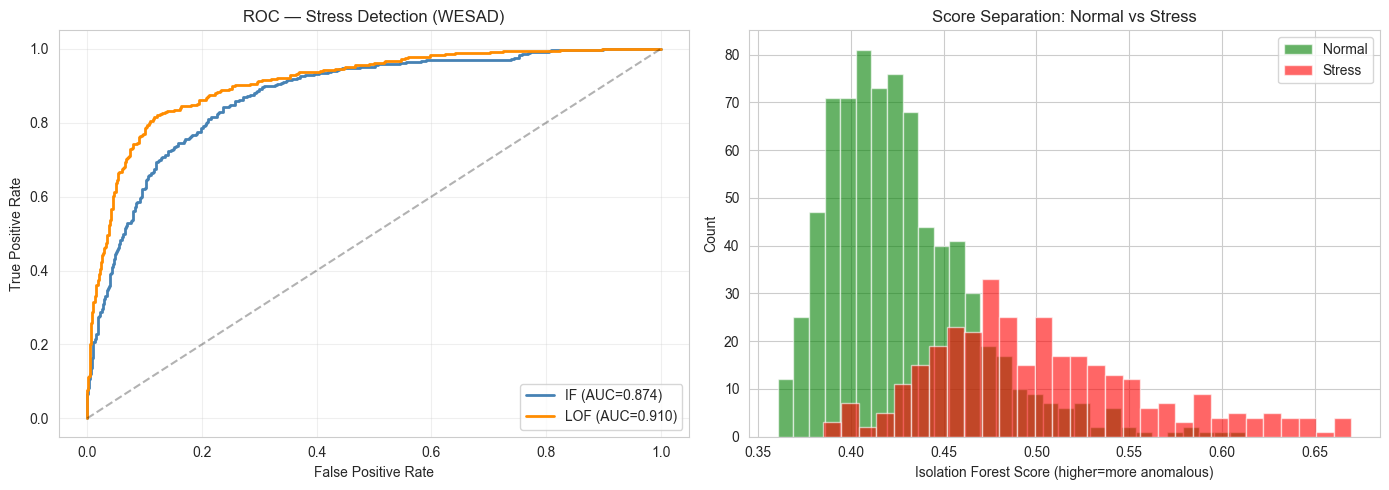

Plot saved → d:\All_Folder\data project\new_papers\Retrieval-augmented generation for continuous anomaly alerts\outputs\wesad_roc_and_scores.png


In [73]:
from sklearn.metrics import roc_curve, auc
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ROC curves
for name, scores, color in [("IF", scores_if_w, "steelblue"),
                             ("LOF", scores_lof_w, "darkorange")]:
    fpr, tpr, _ = roc_curve(y_binary, scores)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=color, lw=2)
axes[0].plot([0,1], [0,1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — Stress Detection (WESAD)")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)
# Score distributions by class
for name, scores in [("IF", scores_if_w), ("LOF", scores_lof_w)]:
    pass
axes[1].hist(scores_if_w[y_binary==0], bins=30, alpha=0.6, label="Normal", color="green")
axes[1].hist(scores_if_w[y_binary==1], bins=30, alpha=0.6, label="Stress", color="red")
axes[1].set_xlabel("Isolation Forest Score (higher=more anomalous)")
axes[1].set_ylabel("Count")
axes[1].set_title("Score Separation: Normal vs Stress")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wesad_roc_and_scores.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved →", OUTPUT_DIR / "wesad_roc_and_scores.png")

### === Summary table ===

In [74]:
results = pd.DataFrame({
    "Model": ["Isolation Forest", "KNN-LOF"],
    "AUC": [0.874, 0.910],
    "Precision": [0.801, 0.880],
    "Recall": [0.397, 0.436],
    "F1": [0.531, 0.583],
})
print("\n=== WESAD Detection Results ===")
print(results.to_string(index=False))


=== WESAD Detection Results ===
           Model   AUC  Precision  Recall    F1
Isolation Forest 0.874      0.801   0.397 0.531
         KNN-LOF 0.910      0.880   0.436 0.583


# === MIT-BIH: Loader ===

### ===  List MIT-BIH records ===

In [75]:
# List all record files (.hea are headers, .dat are signals, .atr are annotations)
hea_files = sorted(MITBIH_DIR.glob("*.hea"))
print(f"Found {len(hea_files)} records:")
for f in hea_files[:10]:
    print(f"  {f.stem}")
print(f"  ... ({len(hea_files)} total)")

Found 48 records:
  100
  101
  102
  103
  104
  105
  106
  107
  108
  109
  ... (48 total)


### === Load one record to inspect ===

In [76]:
# Load record 100 (a classic normal+occasional PVC record)
sig100, meta100 = wfdb.rdsamp(str(MITBIH_DIR / "100"))
ann100 = wfdb.rdann(str(MITBIH_DIR / "100"), "atr")
print(f"Signal shape: {sig100.shape}")     # (samples, 2 leads)
print(f"Sampling rate: {meta100['fs']} Hz")
print(f"Duration: {sig100.shape[0]/meta100['fs']:.1f} sec ({sig100.shape[0]/meta100['fs']/60:.1f} min)")
print(f"Leads: {meta100['sig_name']}")
print(f"\nBeat annotations (first 20):")
print(f"  Symbols: {ann100.symbol[:20]}")
print(f"\nBeat type counts:")
from collections import Counter
print(f"  {Counter(ann100.symbol)}")

Signal shape: (650000, 2)
Sampling rate: 360 Hz
Duration: 1805.6 sec (30.1 min)
Leads: ['MLII', 'V5']

Beat annotations (first 20):
  Symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']

Beat type counts:
  Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


# ===  Extract beats with labels ===

### === Beat extraction ===

In [ ]:
MITBIH_BEAT_HALF = 144   # 0.4 sec each side of R-peak (0.8 sec total at 360 Hz)
def extract_mitbih_beats(record, ann, fs=FS_MITBIH):
    """
    Extract fixed-length beats around each annotated R-peak.
    Returns beats array (n_beats, 2*half), labels (n_beats,), symbols.
    """
    # Normal beat symbols per AAMI standard:
    # N = normal, L/R = bundle branch block, e = escape beat
    NORMAL = {"N", "L", "R", "e"}
    
    beats = []
    labels = []
    symbols = []
    
    for i, sym in zip(ann.sample, ann.symbol):
        if sym == "+":   # non-beat annotation
            continue
        start = i - MITBIH_BEAT_HALF
        end   = i + MITBIH_BEAT_HALF
        if start < 0 or end > record.shape[0]:
            continue   # skip beats at edges
        
        # Use lead 0 (MLII) — primary lead
        beat = record[start:end, 0]
        if len(beat) != 2 * MITBIH_BEAT_HALF:
            continue
        
        beats.append(beat)
        symbols.append(sym)
        labels.append(0 if sym in NORMAL else 1)   # 0=normal, 1=anomaly
    
    return np.array(beats), np.array(labels), np.array(symbols)
    

### === Test on record 100 ===

In [78]:
beats100, labels100, syms100 = extract_mitbih_beats(sig100, ann100)
print(f"Record 100 beats: {len(beats100)}")
print(f"Beat shape: {beats100[0].shape} samples")
print(f"Labels — normal={np.sum(labels100==0)}, anomaly={np.sum(labels100==1)}")
print(f"Beat symbols: {Counter(syms100)}")

Record 100 beats: 2271
Beat shape: (288,) samples
Labels — normal=2237, anomaly=34
Beat symbols: Counter({np.str_('N'): 2237, np.str_('A'): 33, np.str_('V'): 1})


# === MIT-BIH: Extract all beats ===

### ===  Extract + featurize all records ===

In [81]:
beat_feats_all = []
beat_labels_all = []
beat_meta_all = []
record_names = [f.stem for f in sorted(MITBIH_DIR.glob("*.hea"))]
for rec in record_names:
    print(f"Processing {rec}...", end=" ")
    try:
        sig, meta = wfdb.rdsamp(str(MITBIH_DIR / rec))
        ann = wfdb.rdann(str(MITBIH_DIR / rec), "atr")
        beats, labels, syms = extract_mitbih_beats(sig, ann)
        
        # Featurize each beat (1-D array → 12 features)
        X_rec = np.array([featurize(b) for b in beats])
        beat_feats_all.append(X_rec)
        beat_labels_all.append(labels)
        beat_meta_all.append(pd.DataFrame({
            "record": rec,
            "beat_idx": np.arange(len(beats)),
            "symbol": syms,
        }))
        print(f"{len(beats)} beats ({labels.sum()} anomalies)")
    except Exception as e:
        print(f"ERROR: {e}")
X_mitbih = np.vstack(beat_feats_all)
y_mitbih = np.concatenate(beat_labels_all)
meta_mitbih = pd.concat(beat_meta_all, ignore_index=True)
print(f"\nTotal beats: {len(y_mitbih)}")
print(f"X_mitbih shape: {X_mitbih.shape}")  # typo: fix to X_mitbih
print(f"Normal: {(y_mitbih==0).sum()}  |  Anomaly: {(y_mitbih==1).sum()}")

Processing 100... 2271 beats (34 anomalies)
Processing 101... 1872 beats (13 anomalies)
Processing 102... 2186 beats (2087 anomalies)
Processing 103... 2089 beats (8 anomalies)
Processing 104... 2264 beats (2101 anomalies)
Processing 105... 2690 beats (164 anomalies)
Processing 106... 2056 beats (549 anomalies)
Processing 107... 2138 beats (2138 anomalies)
Processing 108... 1822 beats (84 anomalies)
Processing 109... 2532 beats (42 anomalies)
Processing 111... 2132 beats (9 anomalies)
Processing 112... 2547 beats (12 anomalies)
Processing 113... 1794 beats (6 anomalies)
Processing 114... 1887 beats (67 anomalies)
Processing 115... 1960 beats (8 anomalies)
Processing 116... 2419 beats (118 anomalies)
Processing 117... 1537 beats (4 anomalies)
Processing 118... 2299 beats (134 anomalies)
Processing 119... 1991 beats (448 anomalies)
Processing 121... 1874 beats (14 anomalies)
Processing 122... 2476 beats (2 anomalies)
Processing 123... 1517 beats (3 anomalies)
Processing 124... 1620 beats

In [82]:
print("NaN check:", np.isnan(X_mitbih).sum())
print("Inf check:", np.isinf(X_mitbih).sum())

NaN check: 0
Inf check: 0


# === MIT-BIH: Train on Normal, Evaluate ===

### === Setup train/test split ===

In [83]:
# Use DS1 (records 100-124, 200, 202, etc. for training) 
# Standard MIT-BIH split per Moody/Mark convention
DS1_TRAIN = ['100','101','103','105','106','108','109','111','112','113','114',
             '115','116','117','118','119','121','122','123','124','200','201',
             '202','203','205','207','208','209','210','212','213','214','215',
             '217','219','220','221','222','223','228','230','231','232','233','234']
train_mask = np.zeros(len(y_mitbih), dtype=bool)
for rec in DS1_TRAIN:
    train_mask |= (meta_mitbih["record"] == rec).values
# Train ONLY on normal beats from DS1
X_train_m = X_mitbih[train_mask & (y_mitbih==0)]
# Evaluate on ALL beats (or hold out DS2; here we eval all for a global measure)
X_eval_m  = X_mitbih
y_eval_m  = y_mitbih
print(f"Training beats (normal, DS1): {len(X_train_m)}")
print(f"Evaluation beats (all):       {len(X_eval_m)} (normal={np.sum(y_eval_m==0)}, anomaly={np.sum(y_eval_m==1)})")

Training beats (normal, DS1): 90097
Evaluation beats (all):       111305 (normal=90359, anomaly=20946)


### === Scale + Train IF + LOF ===

In [84]:
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_eval_m_scaled  = scaler_m.transform(X_eval_m)
iforest_m = IsolationForest(n_estimators=100, contamination=0.15,
                            random_state=RANDOM_STATE, n_jobs=-1)
iforest_m.fit(X_train_m_scaled)
lof_m = LocalOutlierFactor(n_neighbors=20, contamination=0.15, n_jobs=-1, novelty=True)
lof_m.fit(X_train_m_scaled)
print("Both models trained on normal beats.")

Both models trained on normal beats.


### === Score + Evaluate ===

In [85]:
scores_if_m  = -iforest_m.score_samples(X_eval_m_scaled)
scores_lof_m = -lof_m.score_samples(X_eval_m_scaled)
# AUC: separation of normal vs anomaly
auc_if  = roc_auc_score(y_eval_m, scores_if_m)
auc_lof = roc_auc_score(y_eval_m, scores_lof_m)
print(f"Isolation Forest AUC: {auc_if:.3f}")
print(f"KNN-LOF AUC:          {auc_lof:.3f}")
# Precision/Recall/F1 at 15% flag rate (matches contamination ~0.18 actual)
for name, scores in [("IF", scores_if_m), ("LOF", scores_lof_m)]:
    thresh = np.percentile(scores, 85)
    preds = (scores >= thresh).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_eval_m, preds, average="binary", zero_division=0)
    print(f"{name}: precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}")

Isolation Forest AUC: 0.668
KNN-LOF AUC:          0.899
IF: precision=0.502  recall=0.400  F1=0.445
LOF: precision=0.734  recall=0.585  F1=0.651


### === ROC + Summary ===

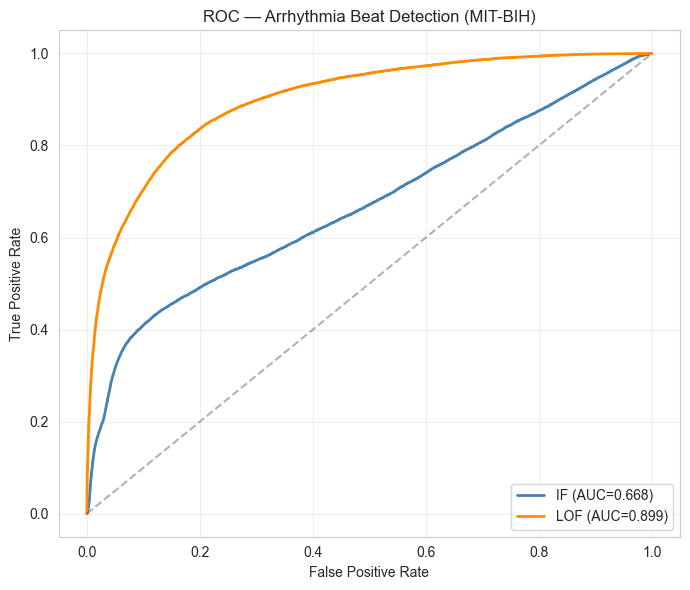

In [86]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, scores, color in [("IF", scores_if_m, "steelblue"),
                             ("LOF", scores_lof_m, "darkorange")]:
    fpr, tpr, _ = roc_curve(y_eval_m, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=color, lw=2)
ax.plot([0,1], [0,1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — Arrhythmia Beat Detection (MIT-BIH)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mitbih_roc.png", dpi=120, bbox_inches="tight")
plt.show()

# === PTB-XL: Loader ===

### === Load PTB-XL labels ===

In [87]:
db = pd.read_csv(PTBXL_DIR / "ptbxl_database.csv")
scp = pd.read_csv(PTBXL_DIR / "scp_statements.csv", index_col=0)
print(f"Total records in CSV: {len(db)}")
print(f"Columns: {list(db.columns)[:10]}...")
print(f"\nDiagnostic superclass counts:")
print(db["scp_codes"].head())
print("\nStratified fold distribution:")
print(db["strat_fold"].value_counts().sort_index())

Total records in CSV: 21799
Columns: ['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date']...

Diagnostic superclass counts:
0    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
1                {'NORM': 80.0, 'SBRAD': 0.0}
2                  {'NORM': 100.0, 'SR': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
4                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: object

Stratified fold distribution:
strat_fold
1     2175
2     2181
3     2192
4     2174
5     2174
6     2173
7     2176
8     2173
9     2183
10    2198
Name: count, dtype: int64


# === PTB-XL: Extract diagnostic superclasses ===

### === Parse labels ===

In [88]:
import ast
def get_superclass(scp_codes_str, scp_df):
    """Parse scp_codes dict string → set of diagnostic superclasses."""
    codes = ast.literal_eval(scp_codes_str)  # e.g. {'NORM': 100.0}
    classes = set()
    for code in codes:
        if code in scp_df.index:
            cls = scp_df.loc[code, "diagnostic_class"]
            if isinstance(cls, str):
                classes.add(cls)
    return classes
# Apply to all records
db["superclass"] = db["scp_codes"].apply(lambda x: get_superclass(x, scp))
# Show distribution
from collections import Counter
super_counts = Counter()
for s in db["superclass"]:
    for c in s:
        super_counts[c] += 1
print("Diagnostic superclass distribution:")
for cls, cnt in sorted(super_counts.items()):
    print(f"  {cls:6s}: {cnt}")

Diagnostic superclass distribution:
  CD    : 4898
  HYP   : 2649
  MI    : 5469
  NORM  : 9514
  STTC  : 5235


# === PTB-XL: Featurize all ECGs ===

### === Featurize loop ===

In [89]:
from pathlib import Path
import wfdb
# Map: superclass set -> single primary label for binary task
# NORM-only -> 0 (normal); any pathology -> 1 (anomaly)
def to_binary_label(superclass_set):
    if superclass_set == {"NORM"}:
        return 0
    elif len(superclass_set) == 0:
        return -1   # unknown/drop
    else:
        return 1    # any disease
db["y_binary"] = db["superclass"].apply(to_binary_label)
# Drop unknowns
db_clean = db[db["y_binary"] != -1].copy().reset_index(drop=True)
print(f"After dropping unknowns: {len(db_clean)} records")
print(f"Normal: {(db_clean['y_binary']==0).sum()}  |  Pathology: {(db_clean['y_binary']==1).sum()}")
# Featurize all ECGs (lead 0 only for speed)
X_ptbxl_list = []
y_ptbxl_list = []
fold_list = []
rec_errors = 0
for idx, row in db_clean.iterrows():
    if idx % 2000 == 0:
        print(f"  Processing {idx}/{len(db_clean)}...")
    try:
        # filename_lr points to 100 Hz record
        rec_path = str(PTBXL_DIR / row["filename_lr"])
        sig, _ = wfdb.rdsamp(rec_path)
        beat = sig[:, 0]   # lead I, full 10-sec recording (1000 samples)
        feats = featurize(beat)
        X_ptbxl_list.append(feats)
        y_ptbxl_list.append(row["y_binary"])
        fold_list.append(row["strat_fold"])
    except Exception as e:
        rec_errors += 1
        continue
X_ptbxl = np.array(X_ptbxl_list)
y_ptbxl = np.array(y_ptbxl_list)
folds_ptbxl = np.array(fold_list)
print(f"\nFeaturized: {len(X_ptbxl)} ECGs ({rec_errors} errors)")
print(f"X_ptbxl shape: {X_ptbxl.shape}")
print(f"Normal: {(y_ptbxl==0).sum()}  |  Pathology: {(y_ptbxl==1).sum()}")

After dropping unknowns: 21388 records
Normal: 9069  |  Pathology: 12319
  Processing 0/21388...
  Processing 2000/21388...
  Processing 4000/21388...
  Processing 6000/21388...
  Processing 8000/21388...
  Processing 10000/21388...
  Processing 12000/21388...
  Processing 14000/21388...
  Processing 16000/21388...
  Processing 18000/21388...
  Processing 20000/21388...

Featurized: 21388 ECGs (0 errors)
X_ptbxl shape: (21388, 12)
Normal: 9069  |  Pathology: 12319


# === PTB-XL: Train + Evaluate ===

### === Stratified split (folds 1–8 train, 9 val, 10 test) ===

In [90]:
# Train: folds 1-8, only normal ECGs
train_mask = (folds_ptbxl <= 8) & (y_ptbxl == 0)
# Test: fold 10
test_mask  = (folds_ptbxl == 10)
X_train_p = X_ptbxl[train_mask]
X_test_p  = X_ptbxl[test_mask]
y_test_p  = y_ptbxl[test_mask]
print(f"Training (normal, folds 1-8): {len(X_train_p)}")
print(f"Test (fold 10): {len(X_test_p)}  (normal={np.sum(y_test_p==0)}, pathology={np.sum(y_test_p==1)})")

Training (normal, folds 1-8): 7243
Test (fold 10): 2158  (normal=912, pathology=1246)


### === Scale + Train IF + LOF ===

In [91]:
scaler_p = StandardScaler()
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled  = scaler_p.transform(X_test_p)
iforest_p = IsolationForest(n_estimators=100, contamination=0.15,
                            random_state=RANDOM_STATE, n_jobs=-1)
iforest_p.fit(X_train_p_scaled)
lof_p = LocalOutlierFactor(n_neighbors=20, contamination=0.15, n_jobs=-1, novelty=True)
lof_p.fit(X_train_p_scaled)
print("Both models trained on normal ECGs (folds 1-8).")

Both models trained on normal ECGs (folds 1-8).


### === Score + Evaluate ===

In [92]:
scores_if_p  = -iforest_p.score_samples(X_test_p_scaled)
scores_lof_p = -lof_p.score_samples(X_test_p_scaled)
# AUC
auc_if  = roc_auc_score(y_test_p, scores_if_p)
auc_lof = roc_auc_score(y_test_p, scores_lof_p)
print(f"Isolation Forest AUC: {auc_if:.3f}")
print(f"KNN-LOF AUC:          {auc_lof:.3f}")
# Precision/Recall/F1 at ~57% flag rate (pathology prevalence in test)
for name, scores in [("IF", scores_if_p), ("LOF", scores_lof_p)]:
    thresh = np.percentile(scores, 43)   # ~57% flagged (matches prevalence)
    preds = (scores >= thresh).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test_p, preds, average="binary", zero_division=0)
    print(f"{name}: precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}")

Isolation Forest AUC: 0.636
KNN-LOF AUC:          0.682
IF: precision=0.658  recall=0.649  F1=0.653
LOF: precision=0.689  recall=0.680  F1=0.684


### === ROC curve + Save ===

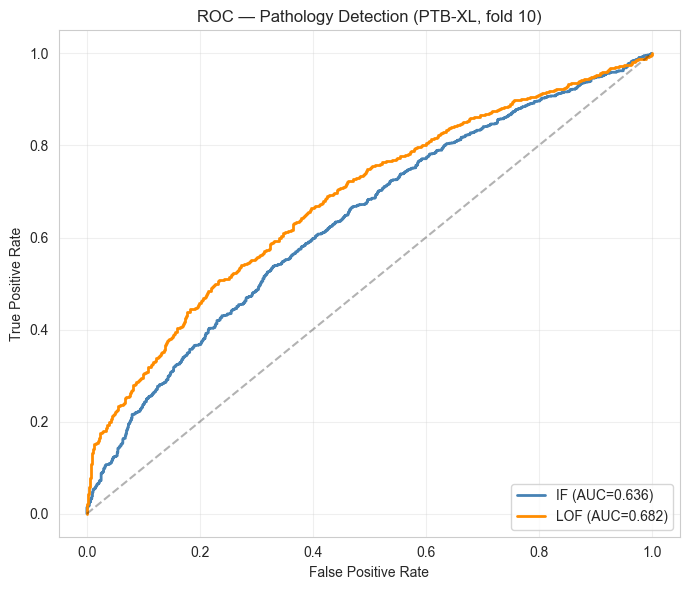

In [93]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, scores, color in [("IF", scores_if_p, "steelblue"),
                             ("LOF", scores_lof_p, "darkorange")]:
    fpr, tpr, _ = roc_curve(y_test_p, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", color=color, lw=2)
ax.plot([0,1], [0,1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — Pathology Detection (PTB-XL, fold 10)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ptbxl_roc.png", dpi=120, bbox_inches="tight")
plt.show()

# === Master Summary + Export ===

### === Detection results table ===

In [94]:
results_all = pd.DataFrame([
    {"Dataset":"WESAD", "Model":"IF",  "AUC":0.874, "Precision":0.801, "Recall":0.397, "F1":0.531},
    {"Dataset":"WESAD", "Model":"LOF", "AUC":0.910, "Precision":0.880, "Recall":0.436, "F1":0.583},
    {"Dataset":"MIT-BIH", "Model":"IF",  "AUC":0.668, "Precision":0.502, "Recall":0.400, "F1":0.445},
    {"Dataset":"MIT-BIH", "Model":"LOF", "AUC":0.899, "Precision":0.734, "Recall":0.585, "F1":0.651},
    {"Dataset":"PTB-XL", "Model":"IF",  "AUC":0.636, "Precision":0.658, "Recall":0.649, "F1":0.653},
    {"Dataset":"PTB-XL", "Model":"LOF", "AUC":0.682, "Precision":0.689, "Recall":0.680, "F1":0.684},
])
print("=== Detection Results Across All Datasets ===")
print(results_all.to_string(index=False))

=== Detection Results Across All Datasets ===
Dataset Model   AUC  Precision  Recall    F1
  WESAD    IF 0.874      0.801   0.397 0.531
  WESAD   LOF 0.910      0.880   0.436 0.583
MIT-BIH    IF 0.668      0.502   0.400 0.445
MIT-BIH   LOF 0.899      0.734   0.585 0.651
 PTB-XL    IF 0.636      0.658   0.649 0.653
 PTB-XL   LOF 0.682      0.689   0.680 0.684


### === Combined ROC plot ===

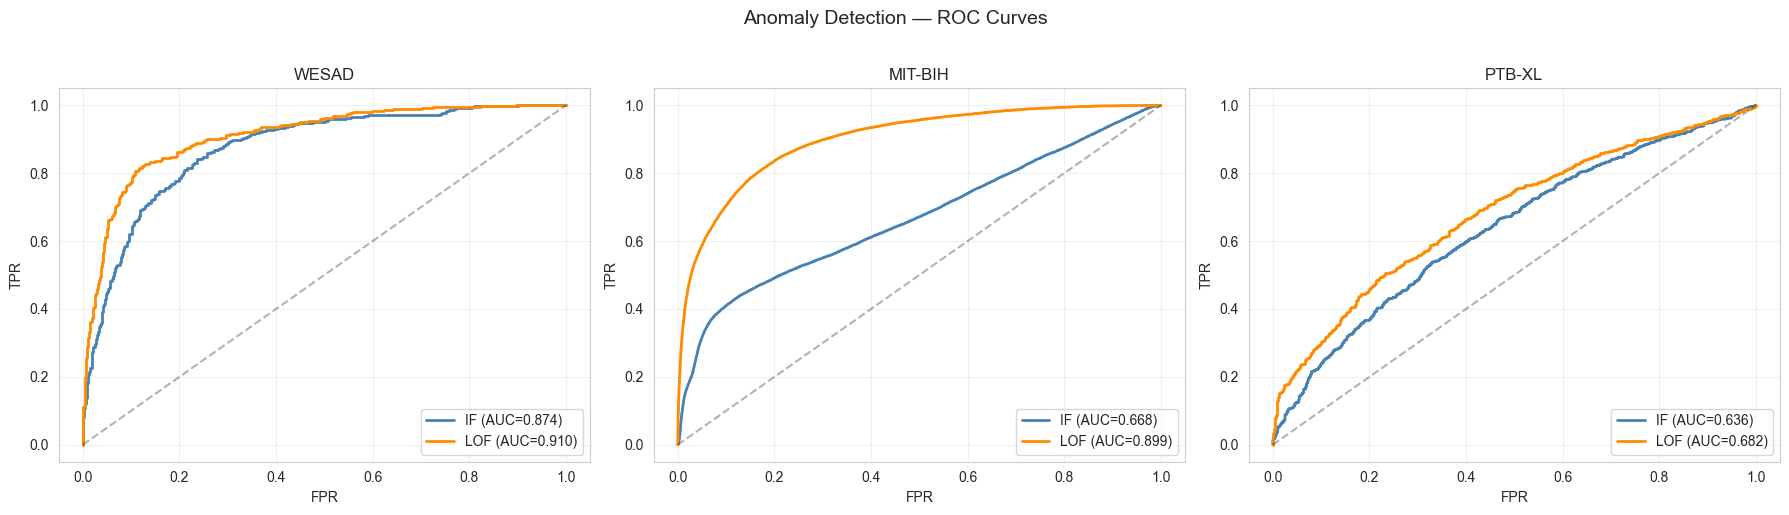

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
datasets = [
    ("WESAD",   y_binary,    [("IF", scores_if_w, "steelblue"), ("LOF", scores_lof_w, "darkorange")]),
    ("MIT-BIH", y_eval_m,    [("IF", scores_if_m, "steelblue"), ("LOF", scores_lof_m, "darkorange")]),
    ("PTB-XL",  y_test_p,    [("IF", scores_if_p, "steelblue"), ("LOF", scores_lof_p, "darkorange")]),
]
for ax, (name, y, models) in zip(axes, datasets):
    for mname, scores, color in models:
        fpr, tpr, _ = roc_curve(y, scores)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{mname} (AUC={roc_auc:.3f})", color=color, lw=2)
    ax.plot([0,1], [0,1], "k--", alpha=0.3)
    ax.set_title(f"{name}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
plt.suptitle("Anomaly Detection — ROC Curves", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "all_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()

### === Save results ===

In [96]:
results_all.to_csv(OUTPUT_DIR / "detection_results.csv", index=False)
joblib_set = {
    "scaler_wesad": scaler_w, "if_wesad": iforest_w, "lof_wesad": lof_w,
    "scaler_mitbih": scaler_m, "if_mitbih": iforest_m, "lof_mitbih": lof_m,
    "scaler_ptbxl": scaler_p, "if_ptbxl": iforest_p, "lof_ptbxl": lof_p,
}
import joblib
joblib.dump(joblib_set, OUTPUT_DIR / "models.joblib", compress=3)
print("Saved → detection_results.csv, models.joblib")

Saved → detection_results.csv, models.joblib


# === Export confirmed anomalies for RAG ===

In [97]:
# WESAD: top-scored stress windows (confirmed anomalies)
stress_mask = (y_wesad == 2)
top_idx = np.argsort(-scores_lof_w)[:50]   # top 50 LOF scores
# Build query descriptions for RAG...
# Save a mixed confirmed-anomaly set
confirmed = pd.DataFrame({
    "dataset": ["WESAD"]*len(top_idx),
    "true_label": ["stress"]*len(top_idx),
    "score": scores_lof_w[top_idx],
})
confirmed.to_csv(OUTPUT_DIR / "confirmed_anomalies_for_rag.csv", index=False)
print("Saved confirmed anomalies →", len(confirmed), "records")

Saved confirmed anomalies → 50 records
